## 1. Load Artifacts (Reuse Pipeline)


In [1]:
import json
import pandas as pd

# Load class mapping
with open("artifacts/class_mapping.json", "r") as f:
    class_to_idx = json.load(f)

class_to_idx = {k: int(v) for k, v in class_to_idx.items()}
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Load split
df = pd.read_csv("artifacts/data_split.csv")

train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "test"]

train_paths = train_df["image_path"].tolist()
train_labels = train_df["label"].tolist()

test_paths = val_df["image_path"].tolist()
test_labels = val_df["label"].tolist()

NUM_CLASSES = len(class_to_idx)

## 2. Dataset + Dataloader

In [2]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_SIZE = 224
BATCH_SIZE = 32

# Transforms
train_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

# Dataset class
class XrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"Invalid image: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]

        label = self.labels[idx]
        return image, label

# Create datasets
train_dataset = XrayDataset(train_paths, train_labels, train_transforms)
val_dataset = XrayDataset(test_paths, test_labels, val_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Build Baseline CNN

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 224 → 112
        x = self.pool(F.relu(self.conv2(x)))  # 112 → 56
        x = self.pool(F.relu(self.conv3(x)))  # 56 → 28

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

## 4. Training Setup

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN(NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 5. Training Loop

In [5]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss:.4f}")

Epoch [1/10], Loss: 11.5933
Epoch [2/10], Loss: 5.2505
Epoch [3/10], Loss: 3.5714
Epoch [4/10], Loss: 2.7078
Epoch [5/10], Loss: 2.0516
Epoch [6/10], Loss: 1.5025
Epoch [7/10], Loss: 1.0407
Epoch [8/10], Loss: 1.1952
Epoch [9/10], Loss: 1.3567
Epoch [10/10], Loss: 1.2372


## 6. Evaluation

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=idx_to_class.values()))

                 precision    recall  f1-score   support

          Covid       0.93      0.96      0.94        26
         Normal       0.95      1.00      0.98        20
Viral Pneumonia       1.00      0.90      0.95        20

       accuracy                           0.95        66
      macro avg       0.96      0.95      0.96        66
   weighted avg       0.96      0.95      0.95        66



## 7. Confusion Matrix

In [7]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[25  1  0]
 [ 0 20  0]
 [ 2  0 18]]


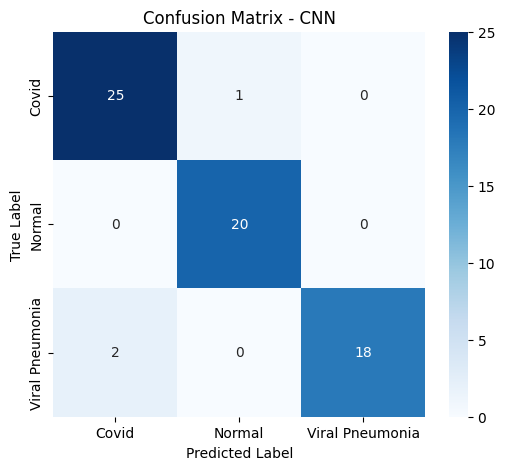

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=idx_to_class.values(),
    yticklabels=idx_to_class.values()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN")

plt.show()

## Save Model

In [9]:
torch.save(model.state_dict(), "artifacts/cnn_model.pth")